# Model Evaluation using Memote

**Phase 2:** [Memote](https://memote.readthedocs.io) is a standardised test suite for genome-scale metabolic models (GEMs). It evaluates annotation completeness, stoichiometric consistency, and network connectivity, producing a scored HTML report. The three curated models from Phase 1 (*iJB1325*, *iMS7199* mature, *iMS7199* green) are evaluated here prior to host-pathogen simulations.

---
* **Author:** Joana Maia  
* **Solver:** Gurobi (Academic Licence)  
* **Core libraries:** COBRApy · Memote · Pandas · Seaborn · Matplotlib  
* **Models evaluated:** *iJB1325* (*A. niger*) · *iMS7199* mature · *iMS7199* green 

---

## Overview of Memote Scoring

Memote organises its $78$ tests into weighted scored sections. The **total score** is a composite of four main sections:

| Section | Description |
|---|---|
| **Annotation** | Database cross-references for metabolites, reactions and genes |
| **Consistency** | Stoichiometric feasibility, mass/charge balance, conservation laws |
| **Network topology** | Blocked, orphan, dead-end, and unbounded reactions; metabolite connectivity |
| **GPR coverage** | Fraction of reactions with gene–protein–reaction rules |

Tests marked **skipped** were omitted due to computational intractability at scale — this is distinct from **failed** and does not indicate a model defect.

## 1. Environment Setup

In [1]:
# !pip install cobra
# !pip install gurobipy
# !pip install matplotlib
# !pip install memote
# !pip install pandas
# !pip install seaborn

In [ ]:
# Standard library
import json, math, os, re
import subprocess
import warnings
warnings.filterwarnings('ignore')

# Numerical / data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# COBRApy and flux analysis tools
import cobra
from cobra.io import read_sbml_model, write_sbml_model
import gurobipy

# Version audit
print(f'COBRApy    : {cobra.__version__}')
print(f'Gurobi     : {".".join(str(v) for v in gurobipy.gurobi.version())}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Seaborn    : {sns.__version__}')

COBRApy    : 0.31.1
Gurobi     : 13.0.2
Matplotlib : 3.10.8
NumPy      : 2.4.4
Pandas     : 2.3.3
Seaborn    : 0.13.2


In [3]:
sns.set_theme(style='whitegrid', context = 'notebook', font_scale = 1.1)
plt.rcParams.update({'figure.dpi'       : 120,
                     'axes.spines.top'  : False,
                     'axes.spines.right': False,
                     'figure.autolayout': True})

C_AN  = '#4A2E6D'  # A. niger — dark purple
C_VVM = '#2D6A4F'  # V. vinifera mature — dark green
C_VVG = '#74C69D'  # V. vinifera green — light green
C_MET = '#1A659E'  # metabolite database
C_RXN = '#E63946'  # reaction database

STATUS_COLOR = {'passed' : "#7BD888", 'failed' : "#F47981", 'skipped': "#737677", 'error'  : "#CC3F35"}

MODELS = {'An'  : {'input' : 'An_curated.xml',         
                   'report': 'An_memotereport.html',
                   'ready' : 'memoteready_An_curated.xml',
                   'label' : 'A. niger iJB1325',        
                   'color' : C_AN},
          'VvM' : {'input' : 'VvM_mature_curated.xml',  
                   'report': 'VvM_memotereport.html',
                   'ready' : 'memoteready_VvM_mature_curated.xml',
                   'label' : 'V. vinifera mature',       
                   'color' : C_VVM},
          'VvG' : {'input' : 'VvG_green_curated.xml',   
                   'report': 'VvG_memotereport.html',
                   'ready' : 'memoteready_VvG_green_curated.xml',
                   'label' : 'V. vinifera green',        
                   'color' : C_VVG},}
KEYS = list(MODELS.keys())

## 2. Model Loading and SBML Round-trip

The three curated models from Phase 1 are loaded and re-exported via COBRApy to ensure SBML compatibility with memote's `libsbml`-based parser.

In [4]:
loaded_models = {}
for key, m in MODELS.items():
    if not os.path.exists(m['input']):
        print(f"[SKIP] {m['input']} not found.")
        continue
    model = read_sbml_model(m['input'])
    mu    = model.optimize().objective_value
    write_sbml_model(model, m['ready'])
    loaded_models[key] = model
    print(f"{m['label']:<25} | {len(model.reactions):>5} rxns "
          f"| {len(model.metabolites):>5} mets | {len(model.genes):>5} genes "
          f"| μ = {mu:.4f} h⁻¹  → {m['ready']}")

'' is not a valid SBML 'SId'.


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2747228
Academic license 2747228 - for non-commercial use only - registered to pg___@uminho.pt
A. niger iJB1325          |  2320 rxns |  1818 mets |  1325 genes | μ = 0.9399 h⁻¹  → memoteready_An_curated.xml
V. vinifera mature        |  4272 rxns |  5143 mets |  7199 genes | μ = 0.1541 h⁻¹  → memoteready_VvM_mature_curated.xml
V. vinifera green         |  4495 rxns |  4399 mets |  6657 genes | μ = 0.1446 h⁻¹  → memoteready_VvG_green_curated.xml


## 3. Memote Snapshot Reports

A scored HTML report is generated for each model. 

The `--skip test_consistency` flag is applied to both *V. vinifera* models due to computational intractability at scale ($4272$–$4495$ reactions).

In [ ]:
MEMOTE_CMDS = {'An' : "memote report snapshot --filename An_memotereport.html  memoteready_An_curated.xml",
               'VvM': "memote report snapshot --filename VvM_memotereport.html --skip test_consistency memoteready_VvM_mature_curated.xml",
               'VvG': "memote report snapshot --filename VvG_memotereport.html --skip test_consistency memoteready_VvG_green_curated.xml",}

# Uncomment to regenerate reports
# for key, cmd in MEMOTE_CMDS.items():
#     print(f'Running memote for {MODELS[key]["label"]}...')
#     result = subprocess.run(cmd, shell=True, capture_output = True, text = True)
#     status = 'Done' if result.returncode == 0 else f'ERROR: {result.stderr[:150]}'
#     print(f'  {status}  →  {MODELS[key]["report"]}')

for key in KEYS:
    fname  = MODELS[key]['report']
    exists = os.path.exists(fname)
    size   = f'{os.path.getsize(fname)/1024:.0f} kB' if exists else 'NOT FOUND'
    print(f"  {MODELS[key]['label']:<20} : {fname:<25} [{size}]")

  A. niger iJB1325     : An_memotereport.html      [4215 kB]
  V. vinifera mature   : VvM_memotereport.html     [8781 kB]
  V. vinifera green    : VvG_memotereport.html     [8462 kB]


## 4. Score Extraction

Memote HTML reports embed all test results as a JSON structure inside the page. The parser below extracts the complete test data (status, metric, data lists) and per-database annotation scores.

**Annotation extraction note:** Database coverage scores are stored as `"score":{...}` JSON blocks in the HTML. Two blocks are relevant: the metabolite annotation block and the reaction annotation block. These are identified by the presence of mutually exclusive database-specific keys.

In [6]:
MET_EXCLUSIVE = frozenset({'chebi','kegg.compound','inchi','inchikey','hmdb','pubchem.compound','metanetx.chemical','bigg.metabolite'})
RXN_EXCLUSIVE = frozenset({'ec-code','rhea','kegg.reaction','seed.reaction','metanetx.reaction','bigg.reaction','brenda'})
ALL_ANN_DBS   = list(MET_EXCLUSIVE | RXN_EXCLUSIVE | {'biocyc','reactome','seed.compound'})

def parse_memote_report(html_path):
    """
    Parse a memote HTML snapshot report.
    Returns dict: total_score, tests, annotation, n_passed, n_failed, n_skipped, n_total
    """
    with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()

    total_m     = re.search(r'"total_score"\s*:\s*([\d.]+)', content)
    total_score = float(total_m.group(1)) * 100 if total_m else None

    tests = {}
    for m in re.finditer(r'"(test_[^"]+)"\s*:\s*\{([^{}]*(?:\{[^{}]*\}[^{}]*)*)\}', content):
        tid  = m.group(1)
        body = m.group(2)
        result_m  = re.search(r'"result"\s*:\s*"([^"]+)"',        body)
        title_m   = re.search(r'"title"\s*:\s*"([^"]+)"',         body)
        metric_m  = re.search(r'"metric"\s*:\s*([\d.]+)',          body)
        data_m    = re.search(r'"data"\s*:\s*(\[[^\]]{0,300}\]|\d+|null)', body)
        tests[tid] = {'result' : result_m.group(1)         if result_m  else 'unknown',
                      'title'  : title_m.group(1)          if title_m   else tid,
                      'metric' : float(metric_m.group(1))  if metric_m  else None,
                      'data'   : data_m.group(1)[:200]     if data_m    else None,}

    score_blocks = re.findall(r'"score"\s*:\s*(\{[^{}]{10,}\})', content)
    ann_scores   = {}
    seen_met     = seen_rxn = False

    for block in score_blocks:
        try:
            data     = json.loads(block)
            keys_set = set(data.keys())
            is_met   = bool(keys_set & MET_EXCLUSIVE)
            is_rxn   = bool(keys_set & RXN_EXCLUSIVE) and not is_met
            if is_met and not seen_met:
                ann_scores.update({k: float(v) for k, v in data.items()
                                   if isinstance(v, (int, float))})
                seen_met = True
            elif is_rxn and not seen_rxn:
                ann_scores.update({k: float(v) for k, v in data.items()
                                   if isinstance(v, (int, float))})
                seen_rxn = True
        except (json.JSONDecodeError, ValueError):
            pass

    n_passed  = sum(1 for t in tests.values() if t['result'] == 'passed')
    n_failed  = sum(1 for t in tests.values() if t['result'] == 'failed')
    n_skipped = sum(1 for t in tests.values() if t['result'] == 'skipped')

    return {'total_score': total_score,
            'tests'      : tests,
            'annotation' : ann_scores,
            'n_passed'   : n_passed,
            'n_failed'   : n_failed,
            'n_skipped'  : n_skipped,
            'n_total'    : len(tests)}


def find_test(tests_dict, title_fragment):
    """Retrieve a test dict by partial title match (case-insensitive)."""
    for tid, t in tests_dict.items():
        if title_fragment.lower() in t.get('title', '').lower():
            return t
    return {}


reports = {}
for key in KEYS:
    fname = MODELS[key]['report']
    if os.path.exists(fname):
        reports[key] = parse_memote_report(fname)
        r = reports[key]
        print(f"{MODELS[key]['label']:<20} | score = {r['total_score']:.1f}%  "
              f"| {r['n_passed']} pass / {r['n_failed']} fail "
              f"/ {r['n_skipped']} skip  ({r['n_total']} tests)")
    else:
        print(f"[SKIP] {fname} not found — run Section 3 first.")

A. niger iJB1325     | score = 29.1%  | 31 pass / 27 fail / 1 skip  (78 tests)
V. vinifera mature   | score = 4.0%  | 30 pass / 14 fail / 15 skip  (78 tests)
V. vinifera green    | score = 4.0%  | 30 pass / 14 fail / 15 skip  (78 tests)


## 5. Summary Score Comparison

Total memote scores and test-status distributions across the three models.

**Score interpretation:** *iMS7199* scores ($4.0\%$) are heavily penalised by the complete absence of metabolite database cross-references. *iJB1325* ($29.1\%$) benefits from ChEBI/KEGG/InChI coverage but is penalised by absent gene annotations and network-topology failures.

Memote Summary
______________________________________________________________________
             Model Total Score (%)  Passed  Failed  Skipped  Total Tests
  A. niger iJB1325            29.1      31      27        1           78
V. vinifera mature             4.0      30      14       15           78
 V. vinifera green             4.0      30      14       15           78


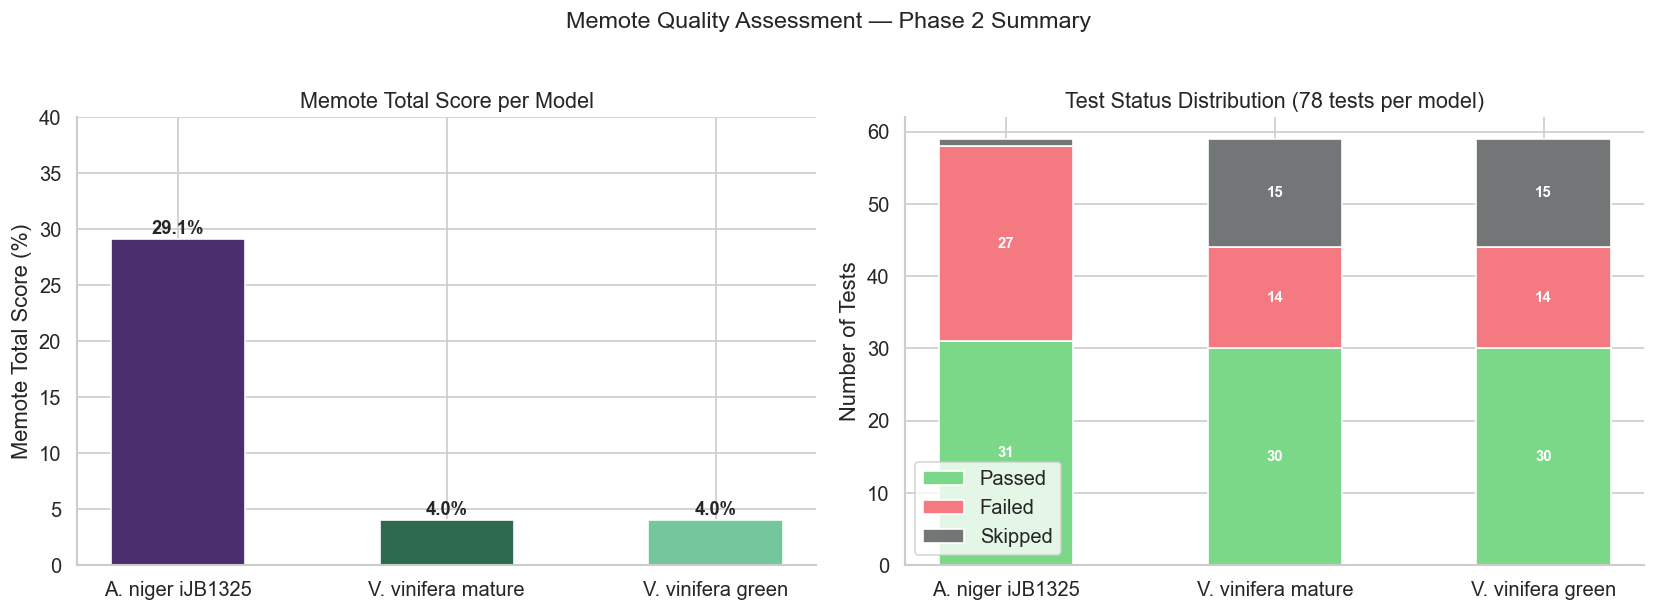

In [7]:
if not reports:
    print("No reports loaded.")
else:
    labels  = [MODELS[k]['label'] for k in KEYS]
    colors  = [MODELS[k]['color'] for k in KEYS]
    scores  = [reports[k]['total_score'] for k in KEYS]
    n_total = reports[KEYS[0]]['n_total']

    # Summary table
    df_summary = pd.DataFrame({'Model'           : labels,
                               'Total Score (%)' : [f'{s:.1f}' for s in scores],
                               'Passed'          : [reports[k]['n_passed']  for k in KEYS],
                               'Failed'          : [reports[k]['n_failed']  for k in KEYS],
                               'Skipped'         : [reports[k]['n_skipped'] for k in KEYS],
                               'Total Tests'     : [reports[k]['n_total']   for k in KEYS],})
    print('Memote Summary')
    print('_' * 70)
    print(df_summary.to_string(index = False))

    fig, axes = plt.subplots(1, 2, figsize = (14, 5))

    # Left
    bars = axes[0].bar(labels, scores, color = colors, edgecolor = 'white', width = 0.5)
    for bar, s in zip(bars, scores):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{s:.1f}%', 
                     ha = 'center', 
                     fontsize = 11, 
                     fontweight = 'bold')
    axes[0].set_ylim(0, 40)
    axes[0].set_ylabel('Memote Total Score (%)')
    axes[0].set_title('Memote Total Score per Model', fontsize = 13)

    # Right
    x = np.arange(len(KEYS))
    w = 0.5
    p_pass = [reports[k]['n_passed']  for k in KEYS]
    p_fail = [reports[k]['n_failed']  for k in KEYS]
    p_skip = [reports[k]['n_skipped'] for k in KEYS]

    axes[1].bar(x, p_pass, w, label = 'Passed',  color = STATUS_COLOR['passed'],  edgecolor = 'white')
    axes[1].bar(x, p_fail, w, label = 'Failed',  color = STATUS_COLOR['failed'],  edgecolor = 'white',
                bottom=p_pass)
    axes[1].bar(x, p_skip, w, label = 'Skipped', color = STATUS_COLOR['skipped'], edgecolor = 'white',
                bottom=[p + f for p, f in zip(p_pass, p_fail)])
    for i, (p, f, s) in enumerate(zip(p_pass, p_fail, p_skip)):
        if p > 1: axes[1].text(i, p/2,         
                               f'{p}', 
                               ha         = 'center', 
                               va         = 'center', 
                               fontsize   = 9,
                               color      = 'white', 
                               fontweight = 'bold')
        if f > 1: axes[1].text(i, p + f/2,     
                               f'{f}', 
                               ha         = 'center', 
                               va         = 'center',
                               fontsize   = 9,
                               color      = 'white', 
                               fontweight = 'bold')
        if s > 1: axes[1].text(i, p + f + s/2, 
                               f'{s}', 
                               ha         = 'center', 
                               va         = 'center', 
                               fontsize   = 9,
                               color      = 'white', 
                               fontweight = 'bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('Number of Tests')
    axes[1].set_title(f'Test Status Distribution ({n_total} tests per model)', fontsize = 13)
    axes[1].legend()

    plt.suptitle('Memote Quality Assessment — Phase 2 Summary', fontsize = 14, y = 1.02)
    plt.tight_layout()
    # plt.savefig('fig1_memote_summary.png', dpi = 150, bbox_inches = 'tight')
    plt.show()

## 6. Annotation Coverage Analysis

Memote scores the fraction of metabolites and reactions annotated with each external database. Two key patterns emerge:

* ***iJB1325*:** Strong **metabolite** annotation — ChEBI ($80.75\%$), KEGG.compound ($54.13\%$), InChI ($46.48\%$) — and solid **reaction** annotation via ec-code ($53.36\%$). This reflects the community-driven curation effort of the *iJB1325* reconstruction.

* ***iMS7199*:** Zero metabolite annotation across all databases, but **~60% ec-code reaction annotation** derived from the enzymatic classifications embedded in the BioCyc reaction entries. This is the only external annotation present in the original *iMS7199* reconstruction.


Database                  A. niger iJB1325 | V. vinifera mature | V. vinifera green
────────────────────────────────────────────────────────────────────────────────
[M] chebi                  :  80.75%    0.00%    0.00%
[M] kegg.compound          :  54.13%    0.00%    0.00%
[M] inchi                  :  46.48%    0.00%    0.00%
[M] inchikey               :   0.00%    0.00%    0.00%
[M] hmdb                   :   0.11%    0.00%    0.00%
[M] pubchem.compound       :   0.00%    0.00%    0.00%
[M] seed.compound          :   0.00%    0.00%    0.00%
[M] metanetx.chemical      :   0.50%    0.00%    0.00%
[M] bigg.metabolite        :   0.00%    0.00%    0.00%
[M] biocyc                 :   0.00%    0.00%    0.00%
[R] ec-code                :  53.36%   60.63%   61.98%
[R] rhea                   :   0.26%    0.00%    0.00%
[R] kegg.reaction          :   0.04%    0.00%    0.00%
[R] seed.reaction          :   0.00%    0.00%    0.00%
[R] metanetx.reaction      :   0.00%    0.00%    0.00%
[R] bigg.

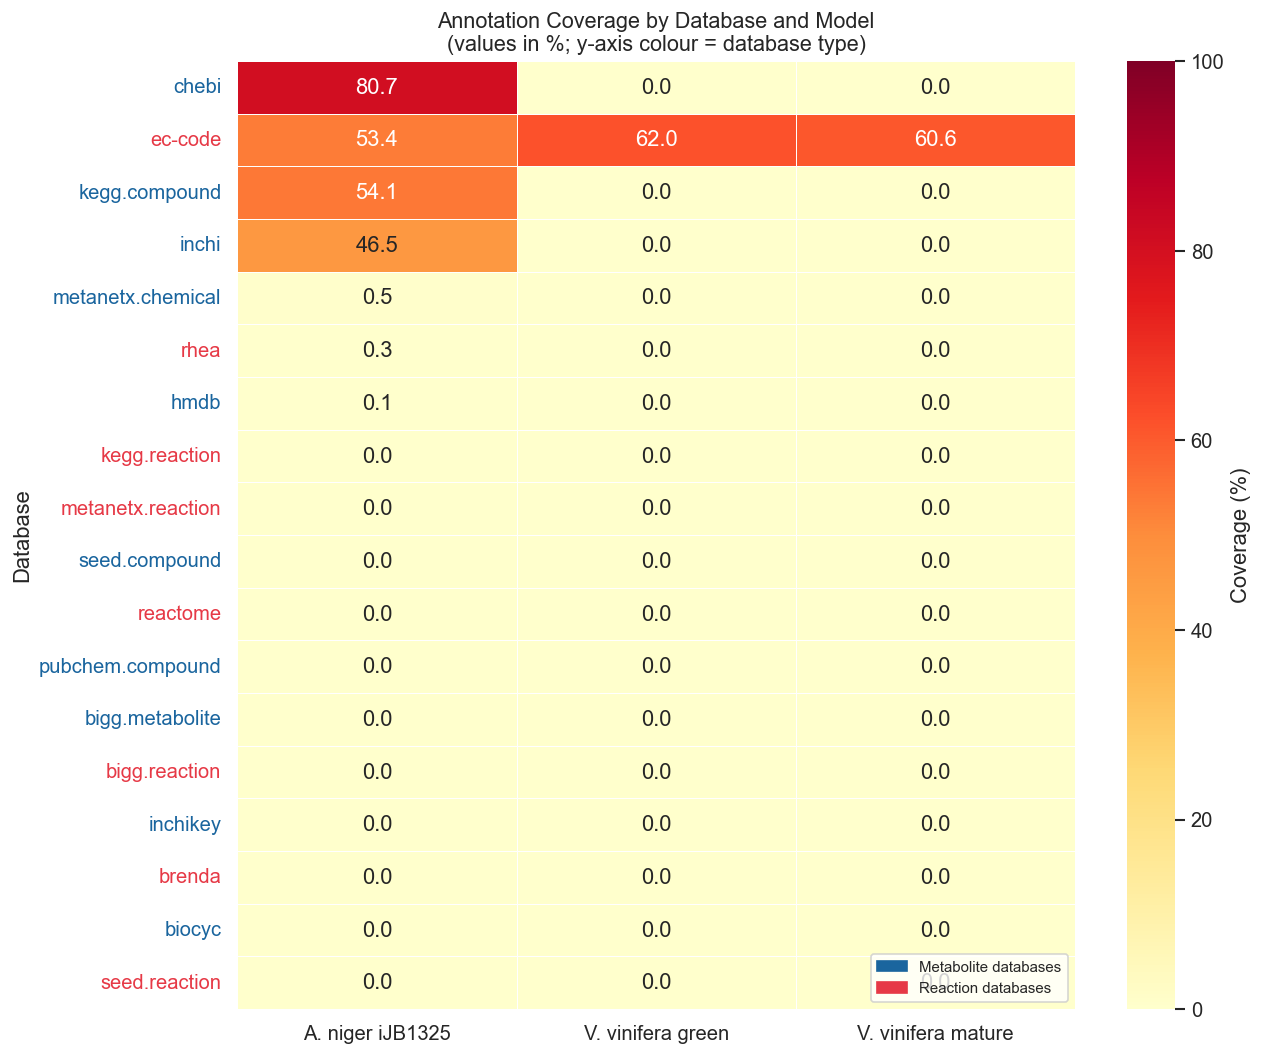

In [8]:
if reports:
    MET_DBS = ['chebi','kegg.compound','inchi','inchikey','hmdb',
               'pubchem.compound','seed.compound','metanetx.chemical','bigg.metabolite','biocyc']
    RXN_DBS = ['ec-code','rhea','kegg.reaction','seed.reaction',
               'metanetx.reaction','bigg.reaction','reactome','brenda']
    DB_TYPE = {db: 'Metabolite' for db in MET_DBS}
    DB_TYPE.update({db: 'Reaction' for db in RXN_DBS})

    print(f'\n{"Database":<25} {" | ".join(MODELS[k]["label"] for k in KEYS)}')
    print('─' * 80)
    for db in MET_DBS + RXN_DBS:
        vals = [reports[k]['annotation'].get(db, 0.0) * 100 for k in KEYS]
        mark = '[R]' if DB_TYPE[db]=='Reaction' else '[M]'
        row  = '  '.join(f'{v:>6.2f}%' for v in vals)
        print(f'{mark} {db:<23}: {row:<10}')

    rows = []
    for db in MET_DBS + RXN_DBS:
        for k in KEYS:
            rows.append({'Model'   : MODELS[k]['label'],
                         'Database': db,
                         'Type'    : DB_TYPE[db],
                         'Coverage': reports[k]['annotation'].get(db, 0.0) * 100})

    df_ann = pd.DataFrame(rows)
    pivot  = df_ann.pivot(index = 'Database', columns = 'Model', values = 'Coverage')
    pivot  = pivot.loc[pivot.max(axis = 1).sort_values(ascending = False).index]

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(pivot,
                annot      = True,
                fmt        = '.1f',
                cmap       = 'YlOrRd',
                vmin       = 0,
                vmax       = 100,
                linewidths = 0.5,
                linecolor  = 'white',
                ax         = ax,
                cbar_kws   = {'label': 'Coverage (%)'})
    for label in ax.get_yticklabels():
        db = label.get_text()
        label.set_color(C_MET if DB_TYPE.get(db) == 'Metabolite' else C_RXN)
    ax.legend(handles = [
        mpatches.Patch(color = C_MET, label = 'Metabolite databases'),
        mpatches.Patch(color = C_RXN, label = 'Reaction databases'),
    ], loc='lower right', fontsize = 9)
    ax.set_title('Annotation Coverage by Database and Model\n'
                 '(values in %; y-axis colour = database type)', fontsize = 13)
    ax.set_xlabel('')
    ax.set_ylabel('Database')
    plt.tight_layout()
    # plt.savefig('fig2_memote_annotation_heatmap.png', dpi = 150, bbox_inches = 'tight')
    plt.show()

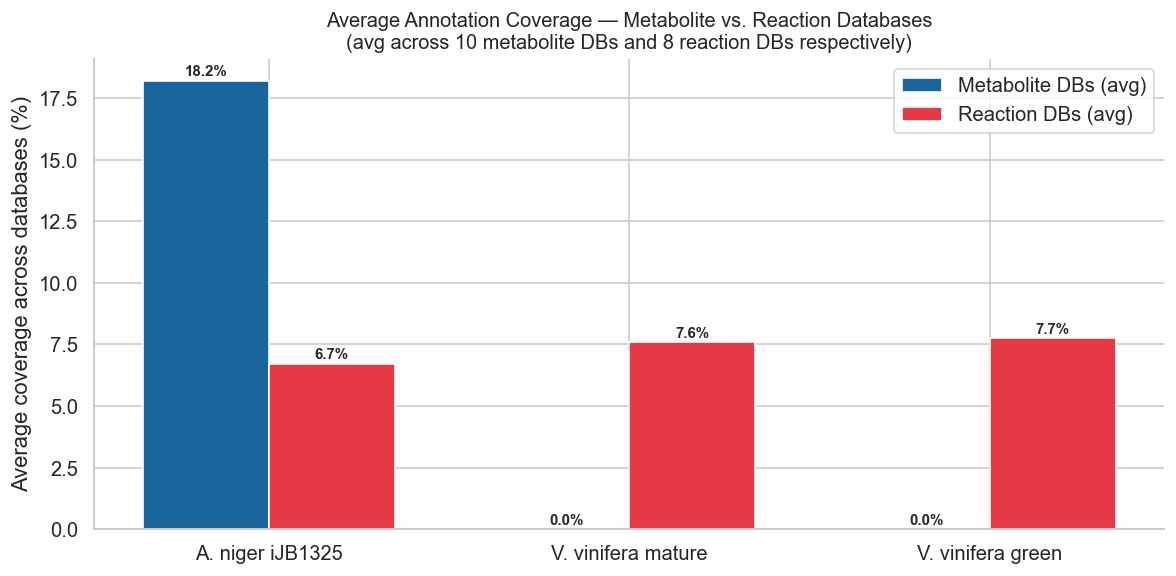


Key findings:
  A. niger iJB1325          ChEBI = 80.7%  KEGG.cmpd = 54.1%  ec-code = 53.4%
  V. vinifera mature        ChEBI = 0.0%  KEGG.cmpd = 0.0%  ec-code = 60.6%
  V. vinifera green         ChEBI = 0.0%  KEGG.cmpd = 0.0%  ec-code = 62.0%


In [9]:
if reports:
    # Grouped bar — average met vs rxn annotation per model
    avg_met = [np.mean([reports[k]['annotation'].get(db, 0.0) for db in MET_DBS]) * 100
               for k in KEYS]
    avg_rxn = [np.mean([reports[k]['annotation'].get(db, 0.0) for db in RXN_DBS]) * 100
               for k in KEYS]

    x = np.arange(len(KEYS))
    w = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    b_met = ax.bar(x - w/2, avg_met, w, label = 'Metabolite DBs (avg)', color = C_MET, edgecolor = 'white')
    b_rxn = ax.bar(x + w/2, avg_rxn, w, label = 'Reaction DBs (avg)',   color = C_RXN, edgecolor = 'white')

    for bar, val in list(zip(b_met, avg_met)) + list(zip(b_rxn, avg_rxn)):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([MODELS[k]['label'] for k in KEYS])
    ax.set_ylabel('Average coverage across databases (%)')
    ax.set_title('Average Annotation Coverage — Metabolite vs. Reaction Databases\n'
                 '(avg across 10 metabolite DBs and 8 reaction DBs respectively)', fontsize = 12)
    ax.legend()
    plt.tight_layout()
    # plt.savefig('fig3_memote_annotation_avg.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nKey findings:')
    for k in KEYS:
        chebi   = reports[k]['annotation'].get('chebi',   0.0) * 100
        kegg_c  = reports[k]['annotation'].get('kegg.compound', 0.0) * 100
        ec      = reports[k]['annotation'].get('ec-code', 0.0) * 100
        print(f"  {MODELS[k]['label']:<25} ChEBI = {chebi:.1f}%  KEGG.cmpd = {kegg_c:.1f}%  ec-code = {ec:.1f}%")

## 7. Complete Test Results Table

Full per-test breakdown across the three models, sorted alphabetically by test title.

**Reading the metric column:**
- **metric = 0.0** on a *passed* test → the measured quantity is absent (e.g. zero mass balance errors) — a positive result
- **metric = 1.0** on a *failed* test → worst-case value (e.g. 100% metabolites lack annotation)
- **skipped** → test omitted due to computational intractability

In [10]:
if reports:
    all_test_ids = sorted(
        set().union(*[set(reports[k]['tests'].keys()) for k in KEYS])
    )
    rows = []
    for tid in all_test_ids:
        row   = {}
        title = ''
        for k in KEYS:
            t      = reports[k]['tests'].get(tid, {})
            result = t.get('result', 'N/A')
            metric = t.get('metric', None)
            sym    = {'passed':'ok','failed':'(!)','skipped':'X','unknown':'?'}.get(result, '?')
            row[MODELS[k]['label']] = f"{sym} {f'{metric:.3f}' if metric is not None else '—'}"
            if not title and t.get('title'):
                title = t['title']
        row['Title'] = title
        rows.append(row)

    df_all = (pd.DataFrame(rows)
              [['Title'] + [MODELS[k]['label'] for k in KEYS]]
              .sort_values('Title'))

    n_tests = len(df_all)
    print(f'Complete Test Results ({n_tests} tests)')
    print('_' * 100)
    pd.set_option('display.max_rows', n_tests + 5)
    pd.set_option('display.max_colwidth', 52)
    print(df_all.to_string(index = False))

Complete Test Results (78 tests)
____________________________________________________________________________________________________
                                            Title A. niger iJB1325 V. vinifera mature V. vinifera green
                                          Biomass              ? —                ? —               ? —
                              Biomass Consistency              ? —                ? —               ? —
            Biomass Production In Complete Medium              ? —                ? —               ? —
             Biomass Production In Default Medium              ? —                ? —               ? —
                     Biomass Reactions Identified         ok 0.000           ok 0.000          ok 0.000
           Biomass Reactions SBO:0000629 Presence        (!) 1.000          (!) 1.000         (!) 1.000
    Blocked Biomass Precursors In Complete Medium              ? —                ? —               ? —
     Blocked Biomass Precursors In

## 8. Detailed Analysis by Category
### 8.1 Network Topology Tests — *A. niger iJB1325*

Network topology tests evaluate structural model quality: connectivity, dead ends, and thermodynamic feasibility. These were executed for *iJB1325* only (skipped for *iMS7199* due to scale).

In [11]:
TOPOLOGY_ENTRIES = [('Universally Blocked Reactions',
                     'Fraction of reactions with zero flux under any condition.\n'
                     'iJB1325: 16.0% blocked — secondary metabolite branches absent under standard media.\n'
                     'Identified: r36a, r36b, r36c, r50ma, r78, r79, r80, r991, r992...'),
                    ('Dead-end Metabolites',
                     'Metabolites produced but never consumed (or vice versa).\n'
                     'iJB1325: 4.8% dead-end — DPTH, DT, DU, GLUP, INAC, LPC, LPE, NAR, PINSP.\n'
                     'Cofactor/lipid intermediates in incomplete biosynthetic branches.'),
                    ('Orphan Metabolites',
                     'Metabolites that participate in only one reaction.\n'
                     'iJB1325: 3.6% — SMNIGB, SMNIGA, SMPESB, SMFUMB2.\n'
                     'Sphingolipid intermediates — incomplete sphingomyelin pathway.'),
                    ('Unbounded Flux',
                     'Reactions capable of infinite flux in the default medium — potential thermodynamic cycles.\n'
                     'iJB1325: 16.2% unbounded — identified in Phase 1A; transport reactions + lumped lipids.'),
                    ('Stoichiometrically Balanced Cycles',
                     'Thermodynamically infeasible energy-generating cycles.\n'
                     'iJB1325: 5.9% — r1, r7, r8, r9, r10, r12a, r14, r15 (peroxisomal β-oxidation).'),
                    ('Mass Balance',
                     'Internal reactions with unbalanced stoichiometry.\n'
                     'iJB1325: 4.3% — r2647, r2648, r1956, r1957, PROTEINpolymm, r2708.\n'
                     'Lumped polymerisation reactions and lipid acyltransferases.'),
                    ('Unconserved Metabolites',
                     'Metabolites not conserved by any conservation law.\n'
                     'iJB1325: 19 metabolites — H2O2, O2, H2O variants across compartments.\n'
                     'Expected for a model with reactive oxygen species chemistry.'),]

an_tests = reports.get('An', {}).get('tests', {})

print('Network Topology — A. niger iJB1325')
print('_' * 70)
for title_frag, interpretation in TOPOLOGY_ENTRIES:
    t      = find_test(an_tests, title_frag)
    result = t.get('result', 'N/A')
    metric = t.get('metric', None)
    sym    = {'passed':'ok','failed':'(!)','skipped':'X'}.get(result, '?')
    m_str  = f'{metric:.3f}' if metric is not None else '—'
    full_t = t.get('title', title_frag)
    print(f'\n{sym} [{result:<7}] metric={m_str}  ─── {full_t}')
    for line in interpretation.split('\n'):
        print(f'   {line}')

Network Topology — A. niger iJB1325
______________________________________________________________________

(!) [failed ] metric=0.160  ─── Universally Blocked Reactions
   Fraction of reactions with zero flux under any condition.
   iJB1325: 16.0% blocked — secondary metabolite branches absent under standard media.
   Identified: r36a, r36b, r36c, r50ma, r78, r79, r80, r991, r992...

(!) [failed ] metric=0.048  ─── Dead-end Metabolites
   Metabolites produced but never consumed (or vice versa).
   iJB1325: 4.8% dead-end — DPTH, DT, DU, GLUP, INAC, LPC, LPE, NAR, PINSP.
   Cofactor/lipid intermediates in incomplete biosynthetic branches.

(!) [failed ] metric=0.036  ─── Orphan Metabolites
   Metabolites that participate in only one reaction.
   iJB1325: 3.6% — SMNIGB, SMNIGA, SMPESB, SMFUMB2.
   Sphingolipid intermediates — incomplete sphingomyelin pathway.

(!) [failed ] metric=0.162  ─── Unbounded Flux In Default Medium
   Reactions capable of infinite flux in the default medium — po

### 8.2 GPR Coverage

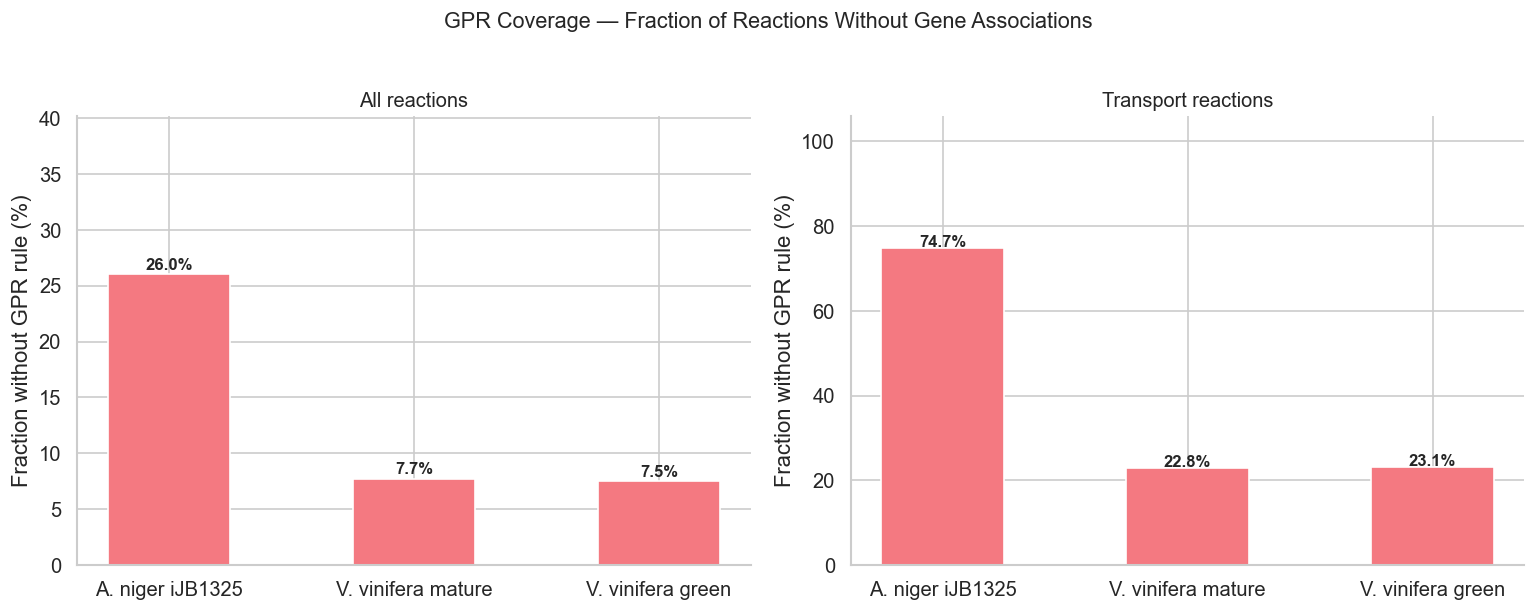

In [12]:
if reports:
    GPR_FRAGS = [('Reactions without GPR',                'All reactions'),
                 ('Fraction of Transport Reactions without', 'Transport reactions')]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, (frag, subtitle) in zip(axes, GPR_FRAGS):
        vals   = []
        colors_ = []
        for k in KEYS:
            t      = find_test(reports[k]['tests'], frag)
            metric = t.get('metric', 0.0) or 0.0
            result = t.get('result', 'N/A')
            vals.append(metric * 100)
            colors_.append(STATUS_COLOR.get(result, '#aaa'))

        bars = ax.bar([MODELS[k]['label'] for k in KEYS], 
                      vals,
                      color = colors_, 
                      edgecolor = 'white', 
                      width = 0.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.4,
                    f'{val:.1f}%', ha = 'center', fontsize = 10, fontweight = 'bold')
        ax.set_ylim(0, max(vals) * 1.35 + 5)
        ax.set_ylabel('Fraction without GPR rule (%)')
        ax.set_title(subtitle, fontsize=12)

    plt.suptitle('GPR Coverage — Fraction of Reactions Without Gene Associations',
                 fontsize = 13, y = 1.02)
    plt.tight_layout()
    # plt.savefig('fig4_memote_gpr.png', dpi = 150, bbox_inches = 'tight')
    plt.show()

### 8.3 Stoichiometric Consistency

In [13]:
if reports:
    CONSISTENCY_FRAGS = ['Stoichiometric Consistency',
                         'Mass Balance',
                         'Charge Balance',
                         'Stoichiometrically Balanced Cycles',
                         'Unconserved Metabolites',
                         'Minimal Inconsistent Net',]

    print('Stoichiometric Consistency Test Results')
    print('_' * 120)
    h = f'{"Test":<50} {"AN":>20} {"VvM":>20} {"VvG":>20}'
    print(h)
    print('_' * 120)

    for frag in CONSISTENCY_FRAGS:
        title = frag
        cells = []
        for k in KEYS:
            t      = find_test(reports[k]['tests'], frag)
            result = t.get('result', 'N/A')
            metric = t.get('metric', None)
            sym    = {'passed':'ok PASS','failed':'(!) FAIL','skipped':'X SKIP'}.get(result, '? N/A')
            m_str  = f'({metric:.3f})' if metric is not None else ''
            cells.append(f'{sym} {m_str}')
            if title == frag and t.get('title'):
                title = t['title']
        print(f'{title[:49]:<50} {cells[0]:>20} {cells[1]:>20} {cells[2]:>20}')

Stoichiometric Consistency Test Results
________________________________________________________________________________________________________________________
Test                                                                 AN                  VvM                  VvG
________________________________________________________________________________________________________________________
Stoichiometric Consistency                             (!) FAIL (1.000)       X SKIP (1.000)       X SKIP (1.000)
Mass Balance                                           (!) FAIL (0.043)       X SKIP (1.000)       X SKIP (1.000)
Charge Balance                                          ok PASS (0.000)       X SKIP (1.000)       X SKIP (1.000)
Stoichiometrically Balanced Cycles                     (!) FAIL (0.059)       X SKIP (1.000)       X SKIP (1.000)
Unconserved Metabolites                               (!) FAIL (19.000)       X SKIP (1.000)       X SKIP (1.000)
Minimal Inconsistent Net Stoichiom

## 9. Adjusted Scores — Annotation-Only Comparison

Raw total scores are misleading for cross-model comparison because *iMS7199* benefits from $15$ skipped tests. Restricting to the annotation scores that are computed for all three models provides a fairer picture.

**Key finding:** *iMS7199* models have ~$60\%$ ec-code reaction coverage (EC numbers from BioCyc), making their reaction annotation broadly comparable to *iJB1325* ($53.4\%$). The critical difference is **metabolite annotation**: *iJB1325* has $18.2\%$ average metabolite coverage vs $0\%$ for *iMS7199*.

Annotation-Focused Scores
______________________________________________________________________________________________________________________________________________________
             Model  Met annotation avg (%)  Rxn annotation avg (%)  Combined annotation avg (%)  ec-code (%)  ChEBI (%)  Total memote score (%)
  A. niger iJB1325                    18.2                    6.71                        12.45         53.4       80.7                    29.1
V. vinifera mature                     0.0                    7.58                         3.79         60.6        0.0                     4.0
 V. vinifera green                     0.0                    7.75                         3.87         62.0        0.0                     4.0


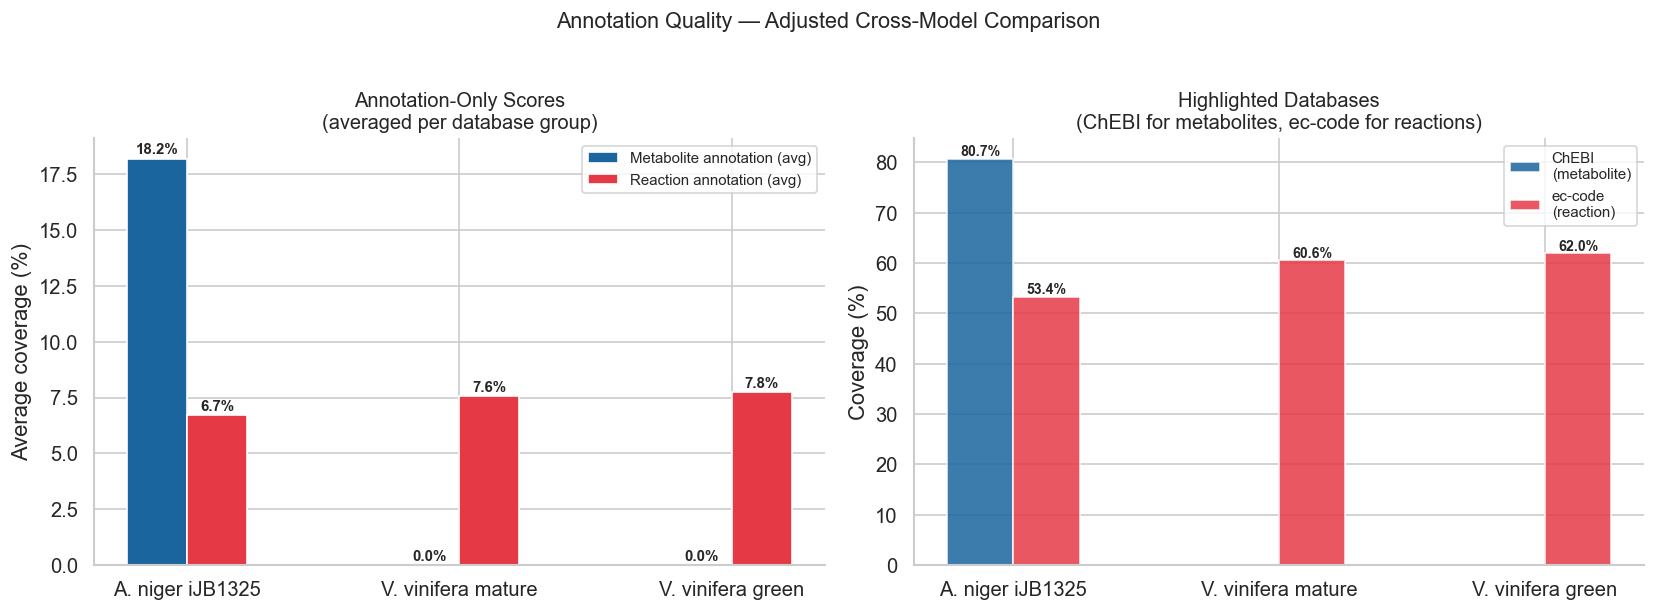

In [14]:
if reports:
    summary_rows = []
    for k in KEYS:
        ann   = reports[k]['annotation']
        m_avg = np.mean([ann.get(db, 0.0) for db in MET_DBS]) * 100
        r_avg = np.mean([ann.get(db, 0.0) for db in RXN_DBS]) * 100
        summary_rows.append({'Model'                      : MODELS[k]['label'],
                             'Met annotation avg (%)'     : round(m_avg, 2),
                             'Rxn annotation avg (%)'     : round(r_avg, 2),
                             'Combined annotation avg (%)': round((m_avg + r_avg) / 2, 2),
                             'ec-code (%)'                : round(ann.get('ec-code', 0.0)*100, 1),
                             'ChEBI (%)'                  : round(ann.get('chebi',   0.0)*100, 1),
                             'Total memote score (%)'     : round(reports[k]['total_score'], 1),})

    df_adj = pd.DataFrame(summary_rows)
    print('Annotation-Focused Scores')
    print('_' * 150)
    print(df_adj.to_string(index = False))

    fig, axes = plt.subplots(1, 2, figsize = (14, 5))

    x = np.arange(len(KEYS))
    w = 0.22

    # Left
    bm = axes[0].bar(x - w/2, 
                     df_adj['Met annotation avg (%)'], 
                     w,
                     label     = 'Metabolite annotation (avg)', 
                     color     = C_MET, 
                     edgecolor = 'white')
    br = axes[0].bar(x + w/2, 
                     df_adj['Rxn annotation avg (%)'], 
                     w,
                     label     = 'Reaction annotation (avg)', 
                     color     = C_RXN, 
                     edgecolor = 'white')
    for bar, val in list(zip(bm, df_adj['Met annotation avg (%)'])) + list(zip(br, df_adj['Rxn annotation avg (%)'])):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f'{val:.1f}%', 
                     ha         = 'center', 
                     fontsize   = 9, 
                     fontweight = 'bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_adj['Model'])
    axes[0].set_ylabel('Average coverage (%)')
    axes[0].set_title('Annotation-Only Scores\n(averaged per database group)', fontsize = 12)
    axes[0].legend(fontsize = 9)

    # Right
    bar_labels  = ['ChEBI\n(metabolite)', 'ec-code\n(reaction)']
    db_list     = ['chebi', 'ec-code']
    n_db        = len(db_list)
    x2          = np.arange(len(KEYS))
    w2          = 0.25
    for i, (db, lbl) in enumerate(zip(db_list, bar_labels)):
        vals   = [reports[k]['annotation'].get(db, 0.0)*100 for k in KEYS]
        col    = C_MET if i == 0 else C_RXN
        offset = (i - (n_db-1)/2) * w2
        bars_  = axes[1].bar(x2 + offset, vals, w2, label = lbl, color = col, edgecolor = 'white', alpha = 0.85)
        for bar, val in zip(bars_, vals):
            if val > 0.5:
                axes[1].text(bar.get_x() + bar.get_width()/2,
                             bar.get_height() + 0.5,
                             f'{val:.1f}%', 
                             ha         = 'center', 
                             fontsize   = 8.5, 
                             fontweight = 'bold')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels([MODELS[k]['label'] for k in KEYS])
    axes[1].set_ylabel('Coverage (%)')
    axes[1].set_title('Highlighted Databases\n(ChEBI for metabolites, ec-code for reactions)', fontsize = 12)
    axes[1].legend(fontsize=9)

    plt.suptitle('Annotation Quality — Adjusted Cross-Model Comparison', fontsize = 13, y = 1.02)
    plt.tight_layout()
    # plt.savefig('fig5_memote_adjusted_scores.png', dpi = 150, bbox_inches = 'tight')
    plt.show()

## 10. Model Quality

A radar chart provides a five-dimension quality profile for each model, normalised to $[0, 1]$ where $1 =$ best. Skipped tests are assigned $0.5$ (neutral) to avoid penalising *iMS7199* for computational limitations.

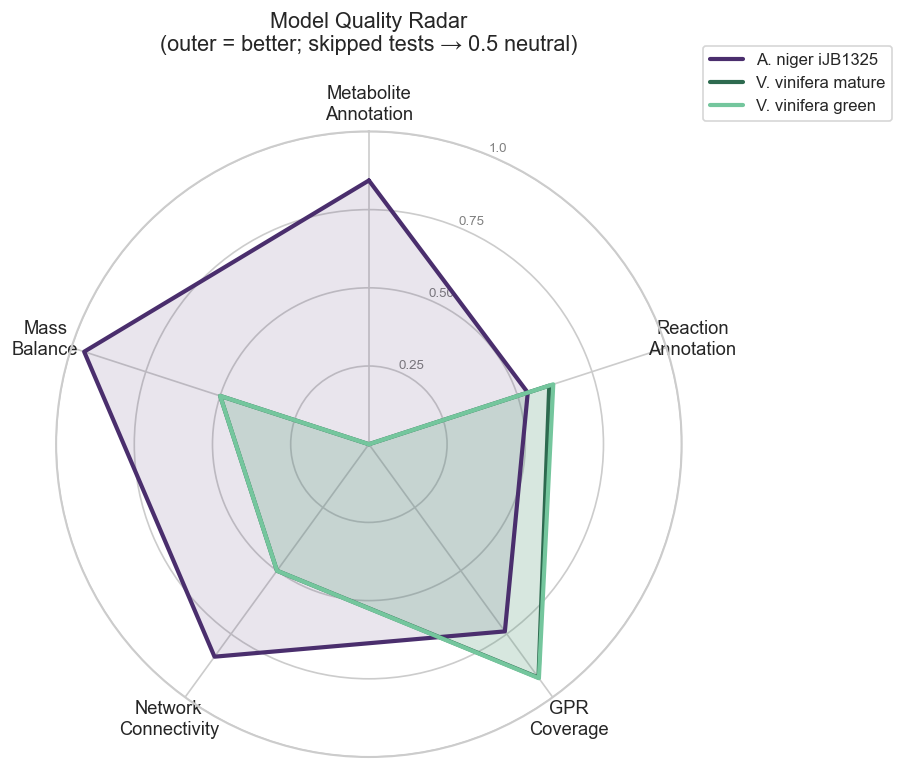

Dimension definitions (all normalised 0–1, higher = better):
  Metabolite Annotation    : 1 − metric
  Reaction Annotation      : 1 − metric
  GPR Coverage             : 1 − metric
  Network Connectivity     : 1 − metric
  Mass Balance             : 1 − metric
  Skipped tests → 0.5 (neutral) to avoid penalising iMS7199 for computational skip.


In [15]:
if reports:
    DIMS = [('Presence of Metabolite Annotation', 'Metabolite\nAnnotation',   True),
            ('Presence of Reaction Annotation',   'Reaction\nAnnotation',     True),
            ('Reactions without GPR',             'GPR\nCoverage',            True),
            ('Universally Blocked Reactions',     'Network\nConnectivity',    True),
            ('Mass Balance',                      'Mass\nBalance',            True),]

    N      = len(DIMS)
    angles = [n / float(N) * 2 * math.pi for n in range(N)] + [0]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

    for k in KEYS:
        vals = []
        for frag, label, invert in DIMS:
            t      = find_test(reports[k]['tests'], frag)
            metric = t.get('metric', None)
            result = t.get('result', 'skipped')
            if metric is None or result == 'skipped':
                v = 0.5
            elif invert:
                v = max(0.0, 1.0 - min(metric, 1.0))
            else:
                v = min(metric, 1.0)
            vals.append(v)
        vals += vals[:1]

        ax.plot(angles, vals, color = MODELS[k]['color'], lw = 2.5, label = MODELS[k]['label'])
        ax.fill(angles, vals, color = MODELS[k]['color'], alpha = 0.12)

    ax.set_theta_offset(math.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([d[1] for d in DIMS], size=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], fontsize = 8, color = 'grey')
    ax.legend(loc='upper right', bbox_to_anchor = (1.35, 1.15), fontsize = 10)
    ax.set_title('Model Quality Radar\n(outer = better; skipped tests → 0.5 neutral)',
                 fontsize = 13, pad = 20)
    plt.tight_layout()
    # plt.savefig('fig6_memote_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Dimension definitions (all normalised 0–1, higher = better):')
    for _, label, invert in DIMS:
        lbl = label.replace('\n', ' ')
        print(f'  {lbl:<25}: {"1 − metric" if invert else "metric directly"}')
    print('  Skipped tests → 0.5 (neutral) to avoid penalising iMS7199 for computational skip.')

## 11. Conclusion

### 11.1 Score Summary

| Model | Total Score | Passed / Failed / Skipped | Note |
|---|---|---|---|
| *A. niger* iJB1325 | **29.1%** | 31 / 27 / 1 | `test_consistency` executed and failed |
| *V. vinifera* mature | **4.0%** | 30 / 14 / 15 | 15 tests skipped (scale) |
| *V. vinifera* green | **4.0%** | 30 / 14 / 15 | 15 tests skipped (scale) |

### 11.2 Computational Skip — *V. vinifera* Models

The `test_consistency` suite was omitted for both *V. vinifera* models via `--skip`. 
This does not indicate inconsistency. Validation was performed in Phases 1B/1C via:

- Round-trip FBA: $|\Delta\mu| < 10^{-6}$ preserved after SBML export and re-import;
- Mass balance audit: one structural error identified (`RXN0-5184__chlo`), with negligible impact on primary carbon fluxes;
- $372$ structurally blocked reactions identified and interpreted in their developmental context.

### 11.3 Annotation Quality

| | Metabolite annotation | Reaction annotation (ec-code) |
|---|---|---|
| *iJB1325* | ChEBI 80.8% · KEGG 54.1% · InChI 46.5% | ec-code **53.4%** |
| *iMS7199* mature | **0%** (BioCyc IDs, no external mapping) | ec-code **60.6%** |
| *iMS7199* green | **0%** | ec-code **62.0%** |

A key finding is that *iMS7199* has substantial **ec-code** annotation (~$60\%$) derived from the enzymatic classifications embedded in BioCyc reaction entries. This means reaction-level annotation is broadly comparable between iJB1325 and iMS7199, and the low total memote scores for *iMS7199* are driven entirely by the absent metabolite-level cross-references — not by a lack of enzymatic annotation.

### 11.4 Key Issues and Impact on Downstream Simulations

| Issue | Model | Impact on co-culture simulation |
|---|---|---|
| Thermodynamic cycles (5.9%) | AN | Potential LP instability; mitigated by r2137 curation (Phase 1A) |
| Blocked reactions (16.0%) | AN | Reduces secondary metabolite routes; no impact on primary carbon fluxes |
| No NGAM | Both | Growth rates represent upper bounds; no maintenance energy penalty |
| Zero metabolite annotation | VvM, VvG | No flux impact; limits database-level interpretation only |
| Mass balance errors (4.3%) | AN | Lumped reactions; individual metabolite balance approximate |
| 19 unconserved metabolites | AN | H₂O₂/O₂ variants; expected for ROS-active model; no flux impact |

All three models are **fit for purpose** for the constraint-based simulations.

## 12. References

* **iJB1325** (Brandl et al., 2018)

Brandl, J., Aguilar-Pontes, M. V., Schäpe, P., Nørregaard, A., Arvas, M., Ram, A. F. J., Meyer, V., Tsang, A., de Vries, R. P., & Andersen, M. R. (2018). A community-driven reconstruction of the *Aspergillus niger* metabolic network. *Fungal Biology and Biotechnology*, *5*, 16. https://doi.org/10.1186/s40694-018-0060-7

* **iMS7199** (Sampaio, M., Rocha, M., & Dias, O., 2024)

Sampaio, M., Rocha, M., & Dias, O. (2024). iMS7199 – genome-scale metabolic model of *Vitis vinifera* (Model ID MODEL2408120001). [Data set]. BioModels. https://biomodels.org/MODEL2408120001